In [26]:
# %% [markdown]
# ## 케인즈 교차선 모형으로부터 IS 곡선 유도 (상하 배치)

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

In [27]:

# 1. 고정된 경제 파라미터 및 정책 변수
c0, c1 = 100, 0.7  # 기초소비, 한계소비성향
i0, i1 = 300, 1000  # 기초투자, 투자의 이자율 민감도
G, T = 200, 100     # 정부지출, 세금
r = 0.15 
# X축 (국민소득 Y의 범위) - 두 그래프의 X축 범위를 똑같이 맞춥니다.
Y_vals = np.linspace(400, 2200, 1000)


In [28]:

def derive_is_vertical(r):
    """
    r: 현재 이자율 (슬라이더로 조절), 이건 리마크. 
    """
    # --- [계산부] ---
    AE_45 = Y_vals
    I_current = i0 - i1 * r  # 금리에 따른 현재 투자량
    AE_planned = c0 + c1 * (Y_vals - T) + I_current + G  # 총지출 곡선
    
    # 균형 국민소득 Y* 계산
    Y_star = (c0 - c1 * T + i0 - i1 * r + G) / (1 - c1)
    
    # 전체 IS 곡선 플롯용 데이터
    r_range = np.linspace(0.01, 0.40, 100)
    Y_IS = (c0 - c1 * T + i0 - i1 * r_range + G) / (1 - c1)
    
    # --- [시각화부: nrows=2, ncols=1로 변경] ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))
    
    # [상단 그래프: 케인즈 교차선]
    ax1.plot(Y_vals, AE_45, label='Y = AE (45° Line)', color='gray', linestyle='--')
    ax1.plot(Y_vals, AE_planned, label=f'Planned AE (at r={r*100:.1f}%)', color='#1f77b4', linewidth=2.5)
    ax1.scatter(Y_star, Y_star, color='red', s=100, zorder=5, label=f'Equilibrium Y* = {Y_star:.0f}')
    
    # 상단 그래프 안내 점선
    ax1.axvline(Y_star, color='red', linestyle=':', alpha=0.4)
    ax1.axhline(Y_star, color='gray', linestyle=':', alpha=0.4)
    
    ax1.set_title('1. Keynesian Cross (Goods Market Equilibrium)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('National Income / Output (Y)')
    ax1.set_ylabel('Aggregate Expenditure (AE)')
    ax1.set_xlim(400, 2200)
    ax1.set_ylim(400, 2200)
    ax1.grid(True, linestyle=':', alpha=0.5)
    ax1.legend(loc='upper left')
    
    # [하단 그래프: IS 곡선 평면]
    ax2.plot(Y_IS, r_range, label='IS Curve', color='purple', linewidth=2.5)
    ax2.scatter(Y_star, r, color='red', marker='o', s=120, zorder=5, 
                 label=f'Current Equilibrium Point')
    
    # 하단 그래프 안내 점선 (상단 그래프의 핵심 Y* 위치와 수직으로 일치하게 됨)
    ax2.axvline(Y_star, color='red', linestyle=':', alpha=0.4)
    ax2.axhline(r, color='red', linestyle=':', alpha=0.4)
    
    ax2.set_title('2. IS Curve Derivation (Y-r Space)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('National Income / Output (Y)')
    ax2.set_ylabel('Interest Rate (r)')
    ax2.set_xlim(400, 2200)
    ax2.set_ylim(0.00, 0.42)
    ax2.grid(True, linestyle=':', alpha=0.5)
    ax2.legend(loc='upper right')
    
    # 상단 위젯의 균형소득(Y*)이 하단으로 그대로 떨어지는 붉은색 수직 관통선 효과
    # 두 그래프의 X축 범위가 400~2200으로 완전히 같기 때문에 일직선으로 정렬됩니다.
    
    plt.tight_layout()
    plt.show()


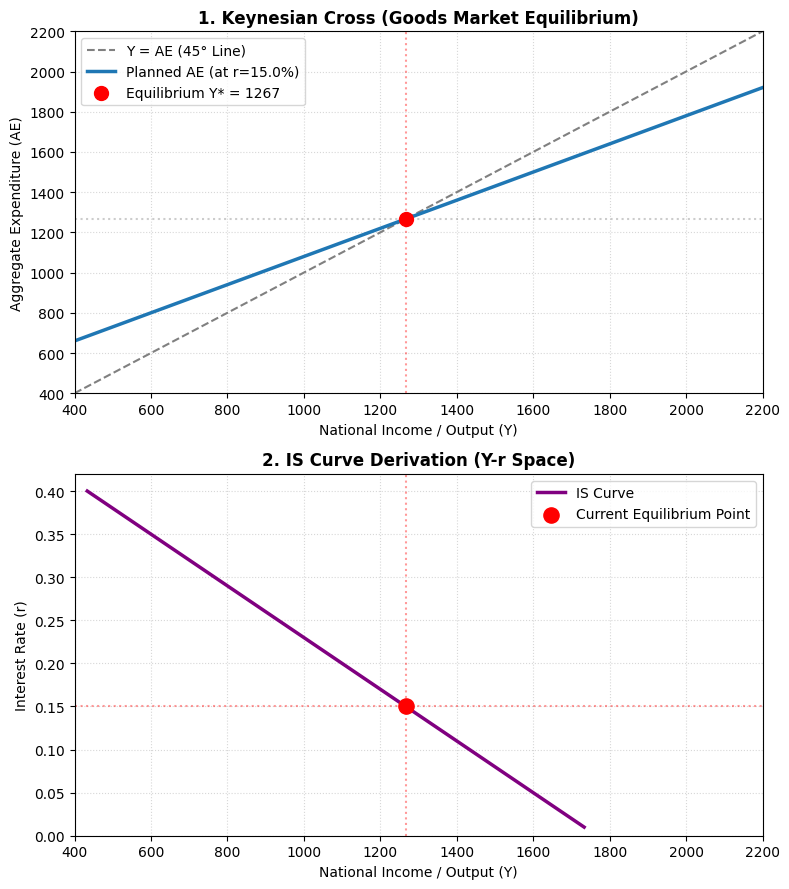

In [29]:

derive_is_vertical(r)